In [ ]:
#Imports
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../data"))

import preprocessing as prep
import utils as utls
import data_splitting as data
import models as mdls
import metrics as mtr


In [ ]:
df_raw = pd.read_csv("../data/raw/rendimiento_estudiantes_dev.csv") 


## Análisis exploratorio de datos

### 1.1 Gráficos y visualización de datos

In [ ]:
print(df_raw.sample(15))

In [ ]:
print(df_raw.isnull().sum())

### Histogramas

In [ ]:
df = df_raw.copy()

ord_rend = {
    "Insuficiente": 0,
    "Regular": 1,
    "Bueno": 2, 
    "Excelente": 3
}

ord_sem = {
    "2022-1": 0,
    "2022-2": 1,
    "2023-1": 2,
    "2023-2": 3,
    "2024-1": 4,
    "2024-2": 5
}

df = prep.ordinal_encoding(df, ord_rend, "rendimiento")
df = prep.ordinal_encoding(df, ord_sem, "semestre") # Me importa el orden cronologico, se podrian hacer solo dos columnas de anio y semestre

fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.flatten()

cols = df.columns.tolist() 

for i, col in enumerate(cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=10)

# Ocultar subplots vacíos si sobran
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

A partir de los histogramas se observa:
- La feature "escuela" mezcla valores en mayúsculas y minúsculas, por lo que todas las variables serán unificados a mayúscula.
- "nota previa" tiene valores hasta 100, aunque los datos se concentran en los valores menores a 10. Esto sugiere que hay una mezcla de escalas, por lo que las notas mayores a 10 se dividen por 10, para unificar la escala.

Las distribuciones de las features parecen ser simétricas.


### Boxplots


In [ ]:
feats = ["horas_estudio","asistencia","nota_previa","horas_sueno","participacion","horas_extracurricular", "distancia_escuela_km","nivel_socioeconomico","tamano_clase"]
utls.boxplots(df, feats)

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, feat in zip(axes.flatten(), feats):
    sns.boxplot(data=df, x='rendimiento', y=feat, ax=ax)
    ax.set_xticks(range(4))
    ax.set_xticklabels(['Insuf', 'Regular', 'Bueno', 'Excelente'])

### Heatmap de correlaciones

In [ ]:
f = feats + ["rendimiento"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[f].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title("Correlaciones entre features")
plt.tight_layout()
plt.show()

In [ ]:
df['aprobado'] = (df['rendimiento'] != 0).astype(int)


fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=130)

# Multiclase
sns.countplot(data=df, x='rendimiento', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución multiclase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cantidad')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{int(bar.get_height())}', ha='center', fontsize=10)

# Binaria
sns.countplot(data=df, x='aprobado', ax=axes[1], color='steelblue')
axes[1].set_title('Distribución binaria', fontsize=13, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Desaprobado (0)', 'Aprobado (1)'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Cantidad')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{int(bar.get_height())}', ha='center', fontsize=10)

plt.suptitle('Distribución de la variable objetivo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df = prep.school_letters(df)
df = prep.one_hot_encoding(df, "escuela")
df = prep.notes_scale(df)

#### Rendimiento

En la versión binaria, el dataset esta altamente desbalanceado. Aproximadamente el 80% de los estudiantes son aprobados, mientras que solo el 16% son desaprobados. Esto significa que ciertos modelos pueden aprneder a predecir siempre 1, que tendría una accuracy muy alta, sin embargo fallaría en detectar a los desaprobados, el cual es el objetivo del modelo. 

En cuanto a la versión multiclase, también hay cierto desbalanceo ya que las clases Excelente y Bueno son las más frecuentes. 

### 1.2 División por escuelas

In [ ]:
feats_numericas = ['horas_estudio', 'asistencia', 'nota_previa', 'horas_sueno',
                   'participacion', 'horas_extracurricular', 'distancia_escuela_km',
                   'nivel_socioeconomico', 'tamano_clase']

label_rend = {v: k for k, v in ord_rend.items()}
label_sem  = {v: k for k, v in ord_sem.items()}


utls.plot_school_analysis(df, feats_numericas, label_rend, label_sem)

Se observan diferencias significativas entre escuelas en varias features:

* En las features nivel socioeconomico, tamaño clase, asistencia, horas estudio y nota previa, las medianas y rangos difieren notablemente entre escuelas.
* En contraste, las features horas de sueño, horas extracurriculares y distancia no muestran una gran variación.

En los gráficos de barras de rendimiento por escuela y por semestre, es notable que el rendimiento varia mayormente según escuela mientras que a nivel temporal, el rendimiento general se mantiene casi constante. Esto se ve también reflejado en la distribución de las clases por escuela. Teniendo en cuenta esto, se podría inferir que las features que más varian entre escuelas son las más influyentes sobre el rendimiento de los alumnos.

### 1.3 Limpieza e imputación de datos


Decisiones de preprocesamiento:

* Unificación de escuelas: Se normalizaron los identificadores de escuela a mayúscula.

* Corrección de escala de notas previas: Los valores mayores a 10 fueron divididos por 10, asumiendo que fueron cargados en escala 0–100 en lugar de 0–10.

* Imputación de valores faltantes: Las features con valores faltantes ("asistencia", "nota_previa", "horas_estudio", "horas_sueno", "participacion" y "nivel_socioeconomico") se imputan con la mediana global del train de cada split. Esto evita data leakage: si se imputara usando agrupaciones por escuela o semestre, esto traería conflictos con ciertos splits (Group y Temporal).

* Normalización: Se aplica normalización z-score a las features numéricas, también calculada solo sobre el train de cada split.

* Encodings: A "semestre" y "rendimiento" se les aplica ordinal encoding para mantener su orden, mientras que a "escuela" se le aplica one hot encoding.

## 2. Clasificación binaria y Estrategias de Splitting

### 2.1 Regresión Logística y Splits

In [ ]:
feats_imp = ["asistencia", "nota_previa", "horas_estudio", "horas_sueno", "participacion", "nivel_socioeconomico"]

# Como cada split tiene un train diferente, se imputa y normaliza dentro de cada uno de ellos
#Split random 80/20
train_set_r, val_set_r = data.random_split(df)
medians_r = prep.medians(train_set_r, feats_imp) #me tengo que guardar los valores con los cuales voy a imputar sobre val y test
train_set_r = prep.impute(train_set_r, medians_r, feats_imp) 
val_set_r = prep.impute(val_set_r, medians_r, feats_imp) 

exclude = ["rendimiento", "aprobado"]
params_r = prep.params_norm(train_set_r, exclude)
train_norm_r = prep.normalize_df(train_set_r, params_r)
val_norm_r = prep.normalize_df(val_set_r, params_r)

# Group split --> Eligo A y G para val ya que tienen distribuciones diferentes de las features (explicar mas)
train_set_g, val_set_g= data.group_split(df, ["A", "G"])
medians_g = prep.medians(train_set_g, feats_imp) 
train_set_g = prep.impute(train_set_g, medians_g, feats_imp) 
val_set_g = prep.impute(val_set_g, medians_g, feats_imp) 

params_g = prep.params_norm(train_set_g, exclude)
train_norm_g = prep.normalize_df(train_set_g, params_g)
val_norm_g = prep.normalize_df(val_set_g, params_g)

# Temporal split
train_set_t, val_set_t= data.temp_split(df)
medians_t = prep.medians(train_set_t, feats_imp) 
train_set_t = prep.impute(train_set_t, medians_t, feats_imp) 
val_set_t = prep.impute(val_set_t, medians_t, feats_imp) 

params_t = prep.params_norm(train_set_t, exclude)
train_norm_t = prep.normalize_df(train_set_t, params_t)
val_norm_t = prep.normalize_df(val_set_t, params_t)





── Metricas de Random Split ──
  accuracy: 0.8755
  precision: 0.8777
  recall: 0.9855
  f1: 0.9285
  auc_roc: 0.9336
  auc_pr: 0.9843


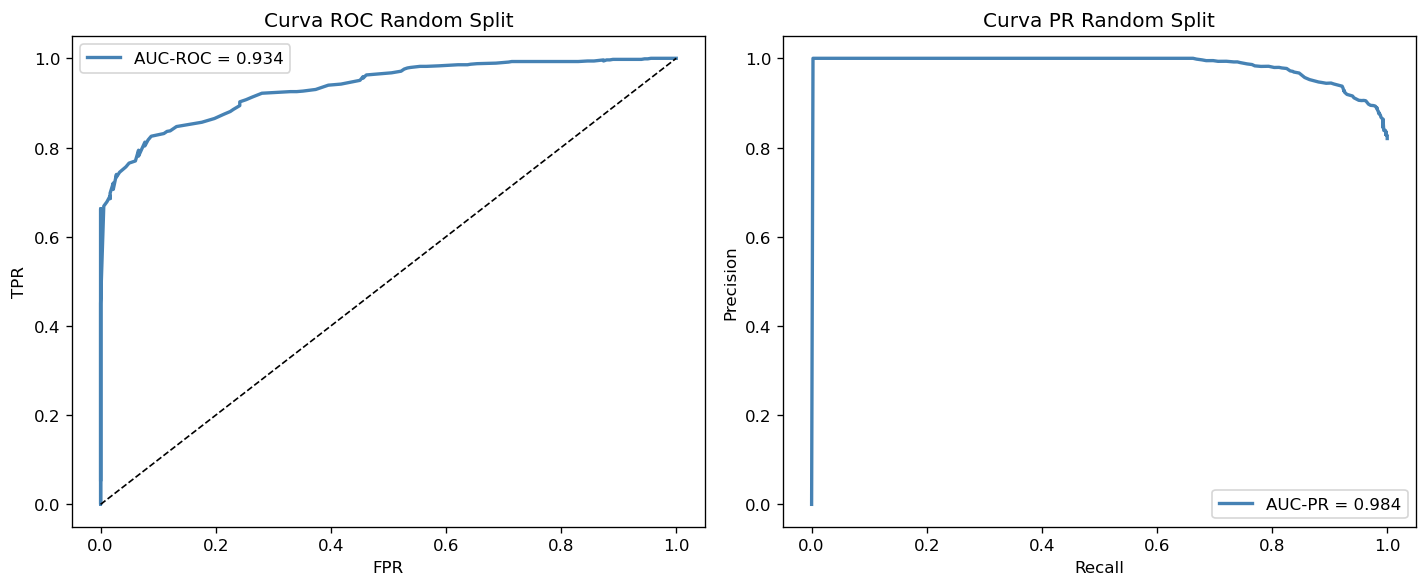

<Axes: title={'center': 'Confusion Matrix'}>

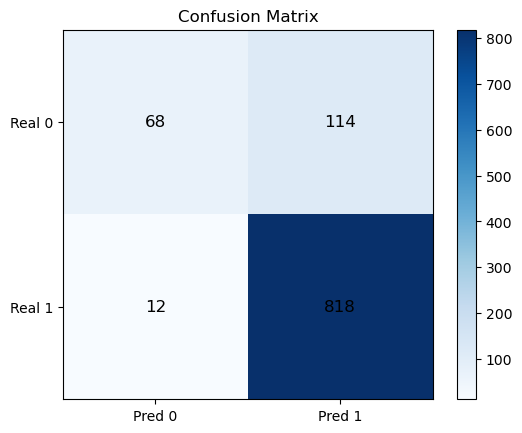

In [ ]:
# Metricas de Random Split
drop_cols = ["escuela", "rendimiento", "aprobado"]
feature_cols = [c for c in df.columns if c not in drop_cols]
X_train_r = train_norm_r[feature_cols].values
y_train_r = train_norm_r["aprobado"].values
X_val_r = val_norm_r[feature_cols].values
y_val_r = val_norm_r["aprobado"].values


model = mdls.LogRegressionL2()
model.set_model(X_train_r, y_train_r)
y_prob_ran = model.predict_prob(X_val_r)
y_pred = model.predict(X_val_r)

metrics = mtr.compute_metrics(y_val_r, y_pred, y_prob_ran)
print(f"\n── Metricas de Random Split ──")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_r, y_prob_ran, title="Random Split")
utls.plot_confusion_matrix(y_val_r, y_pred, title = "Confusion Matrix Random Split")

In [ ]:
# Metricas de Group Split

X_train_g = train_norm_g[feature_cols].values
y_train_g = train_norm_g["aprobado"].values
X_val_g = val_norm_g[feature_cols].values
y_val_g = val_norm_g["aprobado"].values


model_g = mdls.LogRegressionL2()
model_g.set_model(X_train_g, y_train_g)
y_prob_g = model_g.predict_prob(X_val_g)
y_pred_g  = model_g.predict(X_val_g)

metrics_g = mtr.compute_metrics(y_val_g, y_pred_g, y_prob_g)
print(f"\n── Metricas de Group Split ──")
for k, v in metrics_g.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_g, y_prob_g, title="Group Split")
utls.plot_confusion_matrix(y_val_g, y_pred_g, title = "Confusion Matrix Group Split")


── Metricas de Temporal Split ──
  accuracy: 0.9067
  precision: 0.9165
  recall: 0.9824
  f1: 0.9483
  auc_roc: 0.9463
  auc_pr: 0.9916


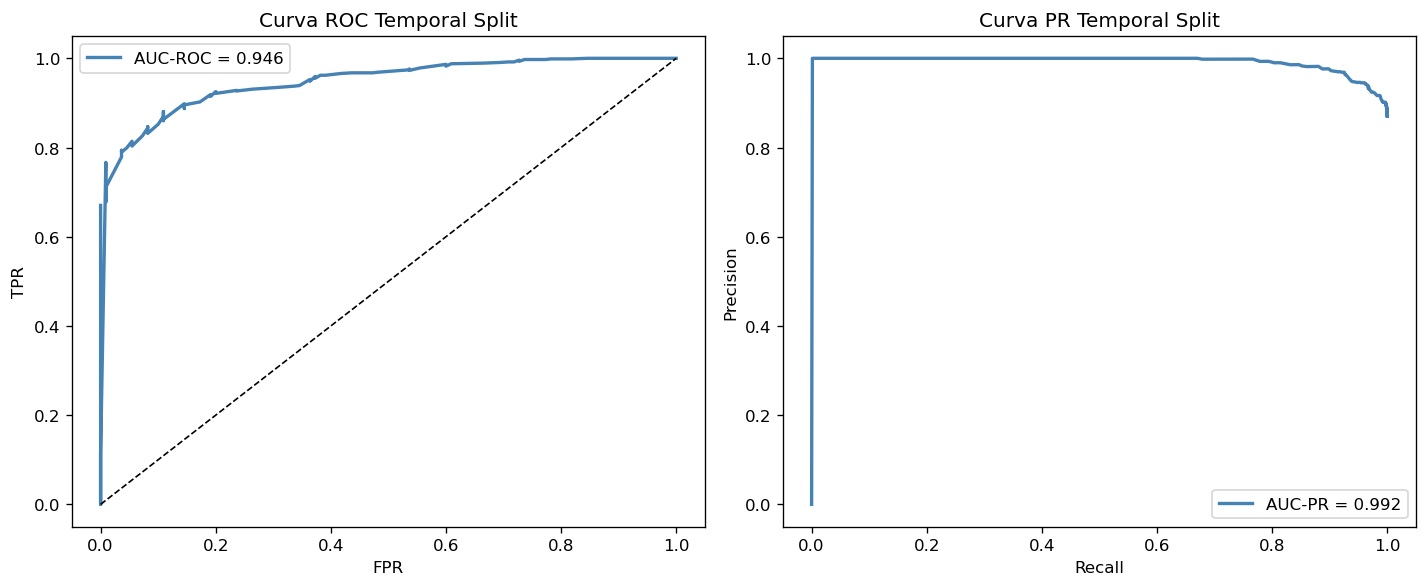

<Axes: title={'center': 'Confusion Matrix'}>

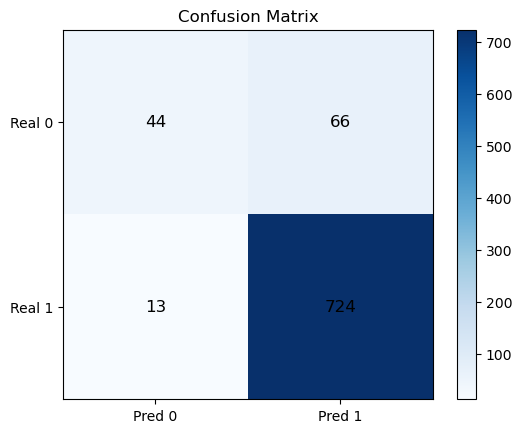

In [ ]:
# Metricas de Temporal Split

X_train_t = train_norm_t[feature_cols].values
y_train_t = train_norm_t["aprobado"].values
X_val_t = val_norm_t[feature_cols].values
y_val_t = val_norm_t["aprobado"].values


model_t = mdls.LogRegressionL2()
model_t.set_model(X_train_t, y_train_t)
y_prob_t = model_t.predict_prob(X_val_t)
y_pred_t = model_t.predict(X_val_t)

metrics_t = mtr.compute_metrics(y_val_t, y_pred_t, y_prob_t)
print(f"\n── Metricas de Temporal Split ──")
for k, v in metrics_t.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_t, y_prob_t, title="Temporal Split")
utls.plot_confusion_matrix(y_val_t, y_pred_t, title = "Confusion Matrix Temporal Split")


### 2.2 Lambda óptimo con Cross Validation

In [ ]:
lambdas = np.logspace(-4, 1, 30)  # de 0.0001 a 100

f1_r = data.cv_lambda_random(df, feature_cols, "aprobado", feats_imp, exclude, lambdas, k=5)
f1_g = data.cv_lambda_group(df,  feature_cols, "aprobado", feats_imp, exclude, lambdas, k=8)

f1_t = []
for lam in lambdas:
    model_l = mdls.LogRegressionL2(lam=lam)
    model_l.set_model(X_train_t, y_train_t)
    y_pred = model_l.predict(X_val_t)
    f1_t.append(mtr.f1(y_val_t, y_pred))
f1_t = np.array(f1_t)

lam_opt_r = lambdas[np.argmax(f1_r)]
lam_opt_g = lambdas[np.argmax(f1_g)]
lam_opt_t = lambdas[np.argmax(f1_t)]

print(f"λ óptimo Random  : {lam_opt_r:.4f}")
print(f"λ óptimo Group   : {lam_opt_g:.4f}")
print(f"λ óptimo Temporal: {lam_opt_t:.4f}")

data.plot_lambda_search(lambdas, f1_r, f1_g, f1_t)

Análisis del λ óptimo por estrategia de splitting:

Los valores de λ óptimo difieren entre las tres estrategias, lo cual refleja que los modelos tienen distintas capacidades de generalización.

* Random Split (λ bajo): El train y val tienen la misma distribución de datos, con escuelas y semestres mezclados. El modelo no necesita regularización fuerte porque no cuenta con un cambio de distribución entre train y validation.

* Group Split (λ más alto): El modelo entrena sobre ciertas escuelas y valida en otras completamente distintas. La regularización es más fuerte para evitar que el modelo se sobreajuste a los datos de las escuelas de entrenamiento, mejorando la capacidad de generalización a escuelas no vistas.

* Temporal Split (λ bajo): Como se observó en el punto 1, la variación entre semestres es mínima. El modelo entrenado en los primeros 5 semestres y validado en el último enfrenta una distribución muy similar, por lo que no requiere una regularización fuerte.

En conclusión, el λ óptimo no es el mismo en los tres casos ya que la necesidad de regularización es mayor cuando la diferencia de la distribución entre train y validación es más significativa.

#### 2.3 Distribución de coeficientes

In [ ]:
#coeficientes para cada estrategia
coefs_random = data.cv_coeficientes_random(df, feature_cols, "aprobado", feats_imp, exclude, lam=lam_opt_r, k=5)
coefs_group = data.cv_coeficientes_group(df, feature_cols, "aprobado", feats_imp, exclude, lam=lam_opt_g, k=8)

# Estabilidad
std_random = coefs_random.std(axis=0)
std_group  = coefs_group.std(axis=0)


# Comparación de desvios
x = np.arange(len(feature_cols))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, std_random, width, label='KFold Aleatorio')
ax.bar(x + width/2, std_group,  width, label='GroupKFold')
ax.set_xticks(x)
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_ylabel("Desvío estándar del coeficiente")
ax.set_title("Estabilidad de coeficientes por estrategia de CV")
ax.legend()
plt.tight_layout()
plt.show()

# Tabla resumen
print("\nDesvío estándar de coeficientes:")
print(f"{'Feature':<25} {'KFold':>10} {'GroupKFold':>12} {'Ratio G/R':>10}")
print("-" * 60)
for feat, sr, sg in zip(feature_cols, std_random, std_group):
    ratio = sg / sr if sr > 0 else float('inf')
    print(f"{feat:<25} {sr:>10.4f} {sg:>12.4f} {ratio:>10.2f}")

Mirando el gráfico y los ratios Group/Random de los coeficientes, las features que presentan mayor inestabilidad frente a GroupKFolds son algunas de las columnas dummies de las escuelas. Luego entre las features originales del dataset, las de mayor desviación son nota_previa, asistencia, tamaño clase y acceso a internet. Los desvios altos implican que esas features son las mas inestables bajo GroupKFolds.
El hecho de que un coeficiente sea inestable cuando la composición de escuelas cambia señala que el peso de esa feature varia mucho dependiendo de la configuración de train y validation con GroupKFolds. Esto significa que existen interacciones entre estas features y las escuelas, siendo que en algunas escuelas las features son más predictivas que en otras. Entonces, el poder predictivo de esas features sobre una nueva escuela que no fue contemplada en train es incierto. 
 
## En que casos se usaria cada uno???

GroupKFold se usaria si se sabe que el test se va a realizar sobre un conjunto de escuelas desconocidas, es decir que no se contemplaron en train. De la manera contraria, RandomKFold se usaria si el modelo se va a utilizar sobre los estudiantes de las mismas escuelas que se utilizaron para entrenar.

### 2.4 Ignorar "escuela" como feature

In [71]:
# Metricas de Random Split
features_cols_es = [c for c in feature_cols if not c.startswith("escuela_")]
X_train_r2 = train_norm_r[features_cols_es].values
y_train_r2 = train_norm_r["aprobado"].values
X_val_r2 = val_norm_r[features_cols_es].values
y_val_r2 = val_norm_r["aprobado"].values


model2 = mdls.LogRegressionL2()
model2.set_model(X_train_r2, y_train_r2)
y_prob_ran2 = model.predict_prob(X_val_r2)
y_pred2 = model.predict(X_val_r2)

metrics2 = mtr.compute_metrics(y_val_r2, y_pred2, y_prob_ran2)
print(f"\n── Metricas de Random Split ──")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_r2, y_prob_ran2, title="Random Split")
utls.plot_confusion_matrix(y_val_r2, y_pred2, title = "Confusion Matrix Random Split (drop escuelas)")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 18 is different from 11)


── Metricas de Group Split ──
  accuracy: 0.7855
  precision: 0.7753
  recall: 0.9912
  f1: 0.8701
  auc_roc: 0.9172
  auc_pr: 0.9694


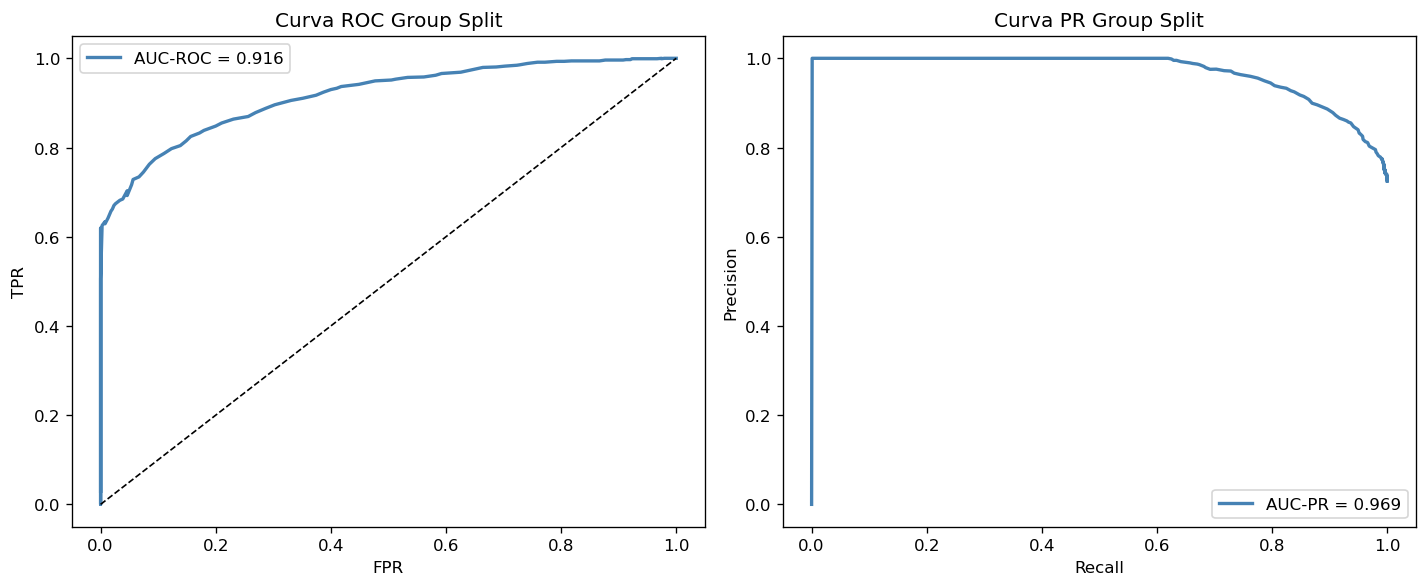

<Axes: title={'center': 'Confusion Matrix Group Split (drop escuelas)'}>

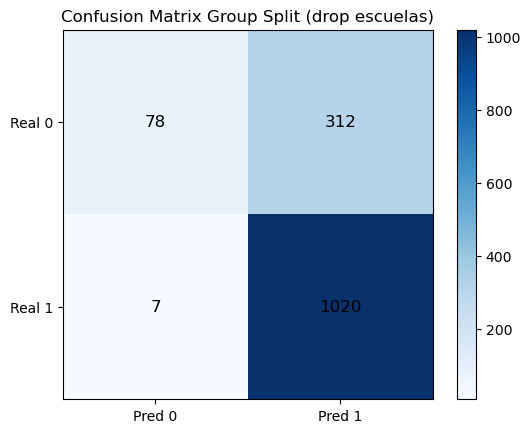

In [69]:
# Metricas de Group Split

X_train_g2 = train_norm_g[features_cols_es].values
y_train_g2 = train_norm_g["aprobado"].values
X_val_g2 = val_norm_g[features_cols_es].values
y_val_g2 = val_norm_g["aprobado"].values


model_g2 = mdls.LogRegressionL2()
model_g2.set_model(X_train_g2, y_train_g2)
y_prob_g2 = model_g2.predict_prob(X_val_g2)
y_pred_g2  = model_g2.predict(X_val_g2)

metrics_g2 = mtr.compute_metrics(y_val_g2, y_pred_g2, y_prob_g2)
print(f"\n── Metricas de Group Split ──")
for k, v in metrics_g.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_g2, y_prob_g2, title="Group Split")
utls.plot_confusion_matrix(y_val_g2, y_pred_g2, title = "Confusion Matrix Group Split (drop escuelas)")


── Metricas de Temporal Split ──
  accuracy: 0.9067
  precision: 0.9165
  recall: 0.9824
  f1: 0.9483
  auc_roc: 0.9463
  auc_pr: 0.9916


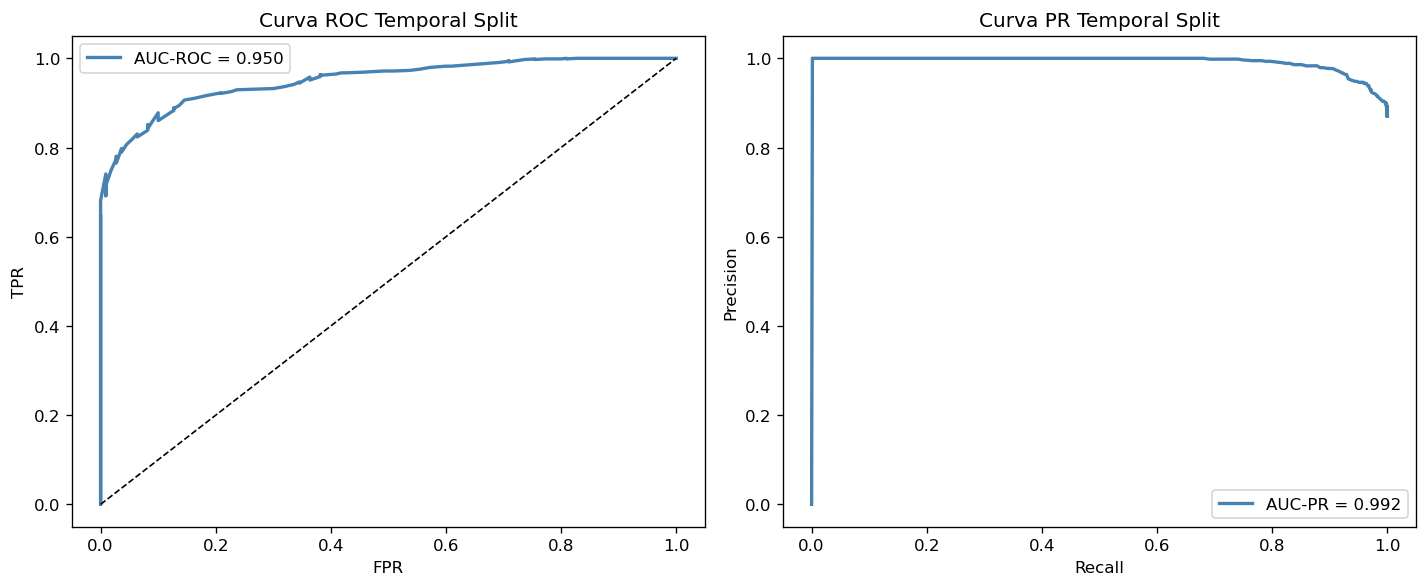

<Axes: title={'center': 'Confusion Matrix Temporal Split (drop escuelas)'}>

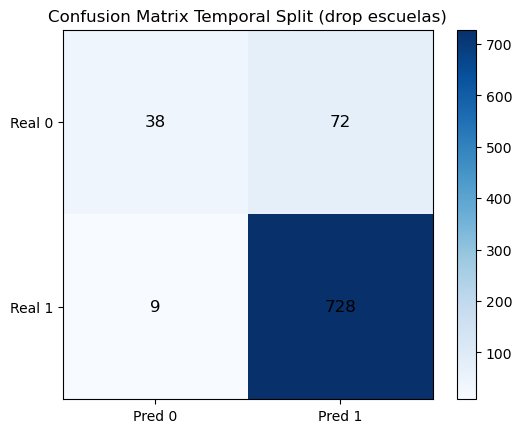

In [70]:
# Metricas de Temporal Split

X_train_t2 = train_norm_t[features_cols_es].values
y_train_t2 = train_norm_t["aprobado"].values
X_val_t2 = val_norm_t[features_cols_es].values
y_val_t2 = val_norm_t["aprobado"].values


model_t2 = mdls.LogRegressionL2()
model_t2.set_model(X_train_t2, y_train_t2)
y_prob_t2 = model_t2.predict_prob(X_val_t2)
y_pred_t2 = model_t2.predict(X_val_t2)

metrics_t2 = mtr.compute_metrics(y_val_t2, y_pred_t2, y_prob_t2)
print(f"\n── Metricas de Temporal Split ──")
for k, v in metrics_t.items():
    print(f"  {k}: {v:.4f}")

utls.plot_roc(y_val_t2, y_prob_t2, title="Temporal Split")
utls.plot_confusion_matrix(y_val_t2, y_pred_t2, title = "Confusion Matrix Temporal Split (drop escuelas)")


## 3. Clasificación Multiclase y Ensamble Learning

In [ ]:
#LDA
y_true_m, y_pred_lda, y_prob_lda = data.cv_group_multiclass(df, feature_cols, "rendimiento", feats_imp, exclude, model_fn=lambda: mdls.LDA())
metrics_lda = mtr.compute_metrics_multiclass(y_true_m, y_pred_lda, y_prob_lda)

rends = {0: "Insuficiente", 1: "Regular", 2: "Bueno", 3: "Excelente"}

print("Modelo LDA\n")
print(f"{'Clase':<15} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC-ROC':>9} {'AUC-PR':>9}")
print("-" * 70)
for k, vals in metrics_lda.items():
    print(f"{rends[k]:<15} "
          f"{vals['accuracy']:>8.4f} "
          f"{vals['precision']:>8.4f} "
          f"{vals['recall']:>8.4f} "
          f"{vals['f1']:>8.4f} "
          f"{vals['auc_roc']:>9.4f} "
          f"{vals['auc_pr']:>9.4f}")

In [ ]:
classes     = [0, 1, 2, 3]

# LDA
utls.plot_roc_multiclass(y_true_m, y_prob_lda, classes, rends, title="ROC - LDA")
utls.plot_pr_multiclass(y_true_m,  y_prob_lda, classes, rends, title="PR - LDA")
utls.plot_confusion_matrix_multiclass(y_true_m, y_pred_lda, rends, title="Confusion Matrix - LDA")

LDA parece colapsar hacia Bueno y Excelente, las dos clases predominantes en el dataset. Se puede ver que los valores de Recall son muy bajos para todas las clases salvo para Excelente. Esto sugiere que las clases no se separan bien linealmente, y el desbalanceo de clases hace que el modelo sesgue sus predicciones hacia las clases con más frecuencia. 

In [ ]:
#Logisitc Regression Multiclase
y_true_m, y_pred_lr, y_prob_lr = data.cv_group_multiclass(df, feature_cols, "rendimiento", feats_imp, exclude, model_fn=lambda: mdls.LogRegressionMulticlass())
metrics_lr = mtr.compute_metrics_multiclass(y_true_m, y_pred_lr, y_prob_lr)

print("Modelo Linear Regression Multiclase\n")
print(f"{'Clase':<15} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC-ROC':>9} {'AUC-PR':>9}")
print("-" * 70)
for k, vals in metrics_lr.items():
    print(f"{rends[k]:<15} "
          f"{vals['accuracy']:>8.4f} "
          f"{vals['precision']:>8.4f} "
          f"{vals['recall']:>8.4f} "
          f"{vals['f1']:>8.4f} "
          f"{vals['auc_roc']:>9.4f} "
          f"{vals['auc_pr']:>9.4f}")


In [ ]:
# Logistic Regression
utls.plot_roc_multiclass(y_true_m, y_prob_lr, classes, rends, title="ROC - Logistic Regression")
utls.plot_pr_multiclass(y_true_m,  y_prob_lr, classes, rends, title="PR - Logistic Regression")
utls.plot_confusion_matrix_multiclass(y_true_m, y_pred_lr, rends, title="Confusion Matrix - Logistic Regression")


In [ ]:
# Random Forest

y_true_m, y_pred_rf, y_prob_rf = data.cv_group_multiclass(df, feature_cols, "rendimiento", feats_imp, exclude, model_fn=lambda: mdls.RandomForest())
metrics_rf = mtr.compute_metrics_multiclass(y_true_m, y_pred_rf, y_prob_rf)

print("Modelo Random Forest\n")
print(f"{'Clase':<15} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC-ROC':>9} {'AUC-PR':>9}")
print("-" * 70)
for k, vals in metrics_rf.items():
    print(f"{rends[k]:<15} "
          f"{vals['accuracy']:>8.4f} "
          f"{vals['precision']:>8.4f} "
          f"{vals['recall']:>8.4f} "
          f"{vals['f1']:>8.4f} "
          f"{vals['auc_roc']:>9.4f} "
          f"{vals['auc_pr']:>9.4f}")

In [ ]:
# Random Forest
utls.plot_roc_multiclass(y_true_m, y_prob_rf, classes, rends, title="ROC - Random Forest")
utls.plot_pr_multiclass(y_true_m,  y_prob_rf, classes, rends, title="PR - Random Forest")
utls.plot_confusion_matrix_multiclass(y_true_m, y_pred_rf, rends, title="Confusion Matrix - Random Forest")



Tanto la Regresión Logística como el Random Forest superan ampliamente a LDA en todas las clases, especialmente en las intermedias (Regular y Bueno) que LDA prácticamente ignoraba.


Regresión Logística Multiclase: Mejora sobre LDA , sin embargo sigue teniendo dificultades con las predicciones de clases intermedias.

A nivel general, Random Forest es el modelo con el mejor desempeño
- Logra el mayor F1 en todas las clases.
- El uso de fronteras de decisión no lineales permiten capturar las interacciones entre features que los modelos lineales no pueden modelar.
- Es más robusto al desbalanceo de clases por al bagging y la selección aleatoria de features.

En conclusión, Random Forest es la elección más adecuada para el problema.


In [ ]:
df_full = prep.impute(df, prep.medians(df, feats_imp), feats_imp)
params_full = prep.params_norm(df_full, exclude)
df_full = prep.normalize_df(df_full, params_full)

X_full = df_full[feature_cols].values
y_full = df_full["rendimiento"].values

model_rf_final = mdls.RandomForest()
model_rf_final.set_model(X_full, y_full)

# 3. Feature importance
importances = model_rf_final.feature_importance()


In [ ]:

# Asociar con nombres de features
feat_imp = list(zip(feature_cols, importances))
feat_imp = sorted(feat_imp, key=lambda x: x[1], reverse=True)

# Imprimir tabla
print(f"{'Feature':<25} {'Importancia':>12}")
print("-" * 40)
for feat, imp in feat_imp:
    print(f"{feat:<25} {imp:>12.4f}")


Los resultados de las importancias coinciden con los analisis realizados previamente. Las features de mayor importancia son tamano_clase, nivel_socioeconomico, asistencia y participacion, las mismas que mostraron mayor inestabilidad de coeficientes en GroupKFold y mayor variabilidad en los boxplots de features segun escuelas. Esto tiene sentido ya que son las features que capturan las diferencias entre las escuelas. 
Por otro lado, se puede ver que tamaño clase tiene una importancia significativamente mayor por sobre el resto, que puede estar relacionado con su alta correlacion con nivel socioeconomico. Esto hace que el modelo distribuya la importancia entre ambas de manera arbitraria.

## 4. Manejo de desbalanceo de clases


In [ ]:
#Primero calculo los lambdas optimos para cada rebalanceo
f1_s = data.cv_lambda_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, lambdas)

ls = lambdas[np.argmax(f1_s)]

print(ls)


In [ ]:
f1_u = data.cv_lambda_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, lambdas, prep.undersampling)
lu = lambdas[np.argmax(f1_u)]

print(lu)


In [ ]:
f1_dup = data.cv_lambda_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, lambdas, prep.oversampling_dup)
ld = lambdas[np.argmax(f1_dup)]

print(ld)


In [ ]:
f1_smote = data.cv_lambda_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, lambdas, prep.smote)
lsmote = lambdas[np.argmax(f1_smote)]
print(lsmote)


In [ ]:
plt.plot(lambdas, f1_dup, label='Oversampling duplicate')
plt.plot(lambdas, f1_smote, label='SMOTE')
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('F1')
plt.legend()
plt.show()

In [ ]:
f1_cr = data.cv_lambda_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, lambdas, reweight=True)
lcr = lambdas[np.argmax(f1_cr)]
print(lcr)

#### Uso los lambdas encontrados para cada modelo con rebalanceos

In [ ]:
#Sin rebalanceo
y_true_s, y_pred_s, y_prob_s = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, ls)



In [ ]:
#under sampling --> eliminar de manera random datos de la clase mayoritaria hasta que quede la mimsma cantidad que la clase minoritaria (igualar proporciones)

y_true_u, y_pred_u, y_prob_u = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, rebalanceo_fn=prep.undersampling, lam=lu)


In [ ]:
#Oversampling por duplicado

y_true_dup, y_pred_dup, y_prob_dup = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, rebalanceo_fn=prep.oversampling_dup, lam=ld)


In [ ]:
#Oversampling por SMOTE

y_true_smote, y_pred_smote, y_prob_smote = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, rebalanceo_fn=prep.smote, lam=lsmote)


In [ ]:
#Cost reweight
y_true_cr, y_pred_cr, y_prob_cr = data.cv_rebalanceo(df, feature_cols, "aprobado", feats_imp, exclude, lam=lcr, reweight=True)


In [ ]:
resultados = {
    "Sin rebalanceo": mtr.compute_metrics(y_true_s, y_pred_s, y_prob_s),
    "Undersampling" : mtr.compute_metrics(y_true_u, y_pred_u, y_prob_u),
    "Oversampling duplicate": mtr.compute_metrics(y_true_dup, y_pred_dup, y_prob_dup),
    "Oversampling SMOTE" : mtr.compute_metrics(y_true_smote, y_pred_smote, y_prob_smote),
    "Cost re-weighting" : mtr.compute_metrics(y_true_cr, y_pred_cr, y_prob_cr),
}

# resumen en tabla
metricas = ["accuracy", "precision", "recall", "f1", "auc_roc", "auc_pr"]
header   = f"{'Modelo':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC-ROC':>10} {'AUC-PR':>10}"
print(header)
print("-" * 90)
for modelo, metrics in resultados.items():
    print(f"{modelo:<25} "
          f"{metrics['accuracy']:>10.4f} "
          f"{metrics['precision']:>10.4f} "
          f"{metrics['recall']:>10.4f} "
          f"{metrics['f1']:>10.4f} "
          f"{metrics['auc_roc']:>10.4f} "
          f"{metrics['auc_pr']:>10.4f}")

In [ ]:
#Matrices de confusion
modelos_preds = [
    ("Sin rebalanceo", y_pred_s),
    ("Undersampling", y_pred_u),
    ("Oversampling duplicate", y_pred_dup),
    ("Oversampling SMOTE", y_pred_smote),
    ("Cost re-weighting", y_pred_cr),
]
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, (name, y_pred) in zip(axes, modelos_preds):
    utls.plot_confusion_matrix(y_true_s, y_pred, title=name, ax=ax)
plt.suptitle("Matrices de Confusión - Técnicas de Rebalanceo", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#Curvas ROC

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_probs = [
    ("Sin rebalanceo", y_prob_s),
    ("Undersampling", y_prob_u),
    ("Oversampling duplicate", y_prob_dup),
    ("Oversampling SMOTE", y_prob_smote),
    ("Cost re-weighting", y_prob_cr),
]

for name, y_prob in models_probs:
    fpr, tpr, auc = mtr.roc_curve(y_true_s, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("Curvas ROC")
axes[0].legend(fontsize=8)


#Curva PR
for name, y_prob in models_probs:
    prec, rec, auc = mtr.precision_recall_curve(y_true_s, y_prob)
    axes[1].plot(rec, prec, label=f"{name} (AUC={auc:.3f})")

baseline = y_true_s.mean()  
axes[1].axhline(baseline, linestyle='--', color='gray', 
                alpha=0.5, label=f"Baseline={baseline:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curvas PR")
axes[1].legend(fontsize=8)

plt.suptitle("Curvas ROC y PR - Técnicas de Rebalanceo", fontsize=13)
plt.tight_layout()
plt.show()

Teniendo en cuenta que el objetivo del modelo es detectar tempranamente a estudiantes en riesgo de bajo rendimiento, se puede pensar que un falso positivo (estudiante de bajo rendimiento predicho de manera erronea) es mas costoso que un flaso negativo. Por eso se pude priorizar el recall por sobre las demas metricas.

Dado que el dataset esta muy desbalanceado entre rendimiento aprobado o desaprobado (binario), accuracy no resulta ser la metrica mas rigurosa para medir el modelo ya que el mismo puede aprender a predecir siempre 1, dejando de lado las predicciones de 0 e igualmente tener una accuracy muy alta. Como el objetivo en este contexto es detectar de manera correcta los ceros 0 (desaprobados), se prioriza recall

Esto hace que el modelo sin rebalanceo, aunque tenga la mayor accuracy, no sea la mejor opcion, ya que detecta los ceros de manera mucho peor a los otros modelos. 
Entonces, se elige oversampling SMOTE como mejor opcion, ya que detecta la mayor cantidad de datos correctos de ambos 

Dado que el objetivo del modelo es detectar tempranamente a estudiantes en riesgo de bajo rendimiento, la métrica más relevante es el Recall de clase 0, no la accuracy global que se ve sesgada por el desbalanceo de clases.


* Sin rebalanceo: tiene la mayor accuracy (0.881) y F1 global (0.932), pero solo detecta aproximadamente el 40% de los estudiantes desaprobados. Esto se debe a que el modelo aprende a predecir casi siempre clase 1, que es la mayoritaria, pudiendo alcanzar una alta accuracy sin aprender la clase minoritaria.

Se puede ver que las técnicas de balanceo resultan en valores más bajos para accuracy y F1 global que sin rebalanceo, pero aumentan el Recall de clase 0 significativamente, detectando correctamente a casi todos los estudiantes en riesgo de bajo rendimeinto. Esta baja en accuracy refleja un aumento en falsos positivos (estudiantes aprobados clasificados como en riesgo), lo cual es una especie de trade-off entre predecir más falsos negativos a cambio de reducir la cantidad de falsos positivos.

Entre las técnicas de rebalanceo los resultados son muy similares, sin embargo se elige Oversampling SMOTE porque obtiene el mejor F1 global entre las técnicas de rebalanceo (0.844).

## 5. Evaluación Final

### 5.1 Selección del mejor modelo

Caso binario:
Para rendimiento como target binario, el mejor modelo es regresión logísitca con regularización L2, rebalanceo de oversampling SMOTE y evaluado con GroupKFolds.

Caso multiclase:
Se elige el modelo Random Forest evaluado con GroupKFolds.

### 5.2 Evaluación sobre test

In [ ]:

# Se preprocesa todo dev
medians_dev = prep.medians(df, feats_imp)
df_dev = prep.impute(df.copy(), medians_dev, feats_imp)
params_dev = prep.params_norm(df_dev, exclude)
df_dev = prep.normalize_df(df_dev, params_dev)

# Cargar y preprocesar test con los mismos parámetros de dev
df_test_raw = pd.read_csv("../data/raw/rendimiento_estudiantes_test.csv")
df_test = df_test_raw.copy()
ord_sem_extended = {**ord_sem, "2025-1": 6}
df_test = prep.ordinal_encoding(df_test, ord_sem_extended, "semestre")
df_test = prep.ordinal_encoding(df_test, ord_rend, "rendimiento")
df_test['aprobado'] = (df_test['rendimiento'] != 0).astype(int)
df_test = prep.school_letters(df_test)
df_test = prep.one_hot_encoding(df_test, "escuela")
df_test = prep.notes_scale(df_test)
df_test = prep.impute(df_test, medians_dev, feats_imp)
df_test = prep.normalize_df(df_test, params_dev)

X_dev_bin = df_dev[feature_cols].values
y_dev_bin = df_dev["aprobado"].values
X_test_bin = df_test[feature_cols].values
y_test_bin = df_test["aprobado"].values


# Entrenar sobre todo dev
X_dev_bal, y_dev_bal = prep.smote(X_dev_bin, y_dev_bin)
model_final_bin = mdls.LogRegressionL2(lam=lsmote)
model_final_bin.set_model(X_dev_bal, y_dev_bal)

y_pred_dev = model_final_bin.predict(X_dev_bin)

# Evaluar sobre test
y_pred_test_bin = model_final_bin.predict(X_test_bin)
y_prob_test_bin = model_final_bin.predict_prob(X_test_bin)

metrics_test_bin = mtr.compute_metrics(y_test_bin, y_pred_test_bin, y_prob_test_bin)
print("── Métricas finales - Binario (test) ──")
for k, v in metrics_test_bin.items():
    print(f"  {k}: {v:.4f}")

utls.plot_confusion_matrix(y_test_bin, y_pred_test_bin, title="Confusion Matrix - Binario (Test)")
utls.plot_roc(y_test_bin, y_prob_test_bin, title="ROC - Binario (Test)")

In [ ]:
# Caso Multiclase
X_dev_mc = df_dev[feature_cols].values
y_dev_mc = df_dev["rendimiento"].values
X_test_mc = df_test[feature_cols].values
y_test_mc = df_test["rendimiento"].values

# Entrenar Random Forest con todo dev
model_final_mc = mdls.RandomForest(random_state=42)
model_final_mc.set_model(X_dev_mc, y_dev_mc)

# Evaluar sobre test
y_pred_test_mc = model_final_mc.predict(X_test_mc)
y_prob_test_mc = model_final_mc.predict_prob(X_test_mc)

metrics_test_mc = mtr.compute_metrics_multiclass(y_test_mc, y_pred_test_mc, y_prob_test_mc)
print("Modelo Random Forest - Test\n")
print(f"{'Clase':<15} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC-ROC':>9} {'AUC-PR':>9}")
print("-" * 70)
for k, vals in metrics_test_mc.items():
    print(f"{rends[k]:<15} "
          f"{vals['accuracy']:>8.4f} "
          f"{vals['precision']:>8.4f} "
          f"{vals['recall']:>8.4f} "
          f"{vals['f1']:>8.4f} "
          f"{vals['auc_roc']:>9.4f} "
          f"{vals['auc_pr']:>9.4f}")

utls.plot_roc_multiclass(y_test_mc, y_prob_test_mc, classes, rends, title="ROC - Random Forest (Test)")
utls.plot_pr_multiclass(y_test_mc,  y_prob_test_mc, classes, rends, title="PR - Random Forest (Test)")
utls.plot_confusion_matrix_multiclass(y_test_mc, y_pred_test_mc, rends, title="Confusion Matrix - Random Forest (Test)")

El set de test pertenece todo al primer semestre de 2025, por lo cual el ordinal encoding de esta feature queda con un solo valor luego del pipeline aplicado. Este shift no debería afectar la performance de los modelos ya que en el análisis de datos de test se vio que el cambio de rendimientos por semestre es prácticamente constante.

### 5.3 Learning curve de Random Forest

In [ ]:
# Split fijo train/test
np.random.seed(42)
n_total = len(X_dev_mc)
test_size = int(0.2 * n_total)
idx = np.random.permutation(n_total)
test_idx = idx[:test_size]
train_idx = idx[test_size:]
X_test_lc = X_dev_mc[test_idx]
y_test_lc = y_dev_mc[test_idx]
X_train_full = X_dev_mc[train_idx]
y_train_full = y_dev_mc[train_idx]

# Modelo completo para definir el target
rf_full = mdls.RandomForest(random_state=42)
rf_full.set_model(X_train_full, y_train_full)
acc_full = mtr.accuracy(y_test_lc, rf_full.predict(X_test_lc))
target_acc = acc_full + 0.01
print(f"Accuracy con todos los datos: {acc_full:.4f}")
print(f"Target (+1%): {target_acc:.4f}\n")

# Learning curve
N_RUNS = 5
train_sizes = np.linspace(0.1, 1.0, 10)
accuracies = []
ns = []

for i, frac in enumerate(train_sizes):
    n = int(frac * len(X_train_full))
    acc_runs = []
    
    for run in range(N_RUNS):
        seed = i * N_RUNS + run
        np.random.seed(seed)
        sample_idx = np.random.choice(len(X_train_full), size=n, replace=False)
        X_tr = X_train_full[sample_idx]
        y_tr = y_train_full[sample_idx]
        
        rf = mdls.RandomForest(random_state=seed)
        rf.set_model(X_tr, y_tr)
        acc_runs.append(mtr.accuracy(y_test_lc, rf.predict(X_test_lc)))
    
    acc_mean = np.mean(acc_runs)
    accuracies.append(acc_mean)
    ns.append(n)
    print(f"n={n}, accuracy={acc_mean:.4f}")

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(ns, accuracies, marker='o', label='Accuracy promedio')
plt.axhline(target_acc, color='r', linestyle='--', label=f'Target: {target_acc:.4f}')
plt.axhline(acc_full, color='g', linestyle=':', label=f'Accuracy actual: {acc_full:.4f}')
plt.xlabel("Cantidad de datos de entrenamiento")
plt.ylabel("Accuracy (test)")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
ultimos_n = ns[-3:]
ultimas_acc = accuracies[-3:]
pendiente = (ultimas_acc[-1] - ultimas_acc[0]) / (ultimos_n[-1] - ultimos_n[0])

#tengo que extrapolar segun los ultimos puntos de la curva para estimar cuantos datos necesitaria agregar para que la learning curve alcance el target de accuracy
n_extra = ns[-1]
acc_extrap = accuracies[-1]
while acc_extrap < target_acc and n_extra < 50000:
    n_extra += 100
    acc_extrap += pendiente * 100

print(f"Accuracy actual (todos los datos dev): {acc_full:.4f}")
print(f"Target (+1 punto porcentual): {target_acc:.4f}")
print(f"Datos actuales en train: {len(X_train_full)}")
print(f"Datos estimados necesarios: {n_extra}")
print(f"Datos a agregar: aprox {n_extra - len(X_train_full)}")
